# IndabaX Botswana Hackathon 2026
## Forecasting Botswana's Food Price Inflation Under Global Economic Shocks

### Notebook 03: Classical Baseline — SARIMAX

**Purpose:** Fits and validates a SARIMAX(1,1,1)(1,0,1,12) model
using forecast-safe (lag-12) exogenous features. Compares against
a seasonal naive baseline. Produces residual diagnostics (ACF,
Ljung-Box test) and the actual-vs-forecast visualisation required
by the Model Comparison Report.

**Input:** `data/processed/modelling_table_with_lags.csv`
**Output:** SARIMAX validation RMSE/MAE, figures in `outputs/figures/`

In [42]:
# ── Imports ──
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [43]:
# load data
df_with_lags = pd.read_csv('../data/processed/modelling_table_with_lags.csv')
df_with_lags['year_month'] = pd.to_datetime(df_with_lags['year_month'])


In [44]:
# ── Forecast-safe exogenous features (lag12 only, resolve to known 2023-or-earlier data) ──
exog_cols_safe = [
    'target_food_price_inflation_lag12',
    'hcp_zaf_fao_cp_23014_lag12',
    'brent_yoy_pct_lag12',
    'brent_usd_per_barrel_lag12',
    'policy_rate_lag12',
    'bdi_close_mean_lag12',
    'month_sin', 'month_cos'
]

selected_cols_safe = ['year_month', 'target_food_price_inflation'] + exog_cols_safe
model_df_safe = df_with_lags[selected_cols_safe].dropna().reset_index(drop=True)
print('model_df_safe shape:', model_df_safe.shape)


model_df_safe shape: (264, 10)


In [45]:
# ── Three-way chronological split ──
train = model_df_safe[model_df_safe['year_month'] <= '2020-12']
val = model_df_safe[(model_df_safe['year_month'] > '2020-12') & (model_df_safe['year_month'] <= '2022-12')]
holdout = model_df_safe[(model_df_safe['year_month'] > '2022-12') & (model_df_safe['year_month'] <= '2023-12')]

y_train = train['target_food_price_inflation']
y_val = val['target_food_price_inflation']
y_holdout = holdout['target_food_price_inflation']

exog_train = train[exog_cols_safe]
exog_val = val[exog_cols_safe]
exog_holdout = holdout[exog_cols_safe]

print('Train:', train.shape, 'Val:', val.shape, 'Holdout:', holdout.shape)


Train: (227, 10) Val: (24, 10) Holdout: (12, 10)


In [46]:
# ── Fit SARIMAX on train, validate on val ──
sarimax_safe = SARIMAX(y_train, exog=exog_train, order=(1,1,1), seasonal_order=(1,0,1,12)).fit(disp=False)
val_forecast = sarimax_safe.forecast(len(y_val), exog=exog_val)

rmse = np.sqrt(mean_squared_error(y_val, val_forecast))
mae = mean_absolute_error(y_val, val_forecast)
print('SARIMAX (safe features) val RMSE:', rmse, 'MAE:', mae)

SARIMAX (safe features) val RMSE: 6.220350063658722 MAE: 4.810617742558658


In [47]:
# naive baseline comparison 
naive_forecast = val.set_index('year_month')['target_food_price_inflation_lag12']
naive_actual = val.set_index('year_month')['target_food_price_inflation']

naive_rmse = np.sqrt(mean_squared_error(naive_actual, naive_forecast))
print('Naive (seasonal) RMSE:', naive_rmse)

Naive (seasonal) RMSE: 5.760895535013828


Text(0.5, 1.0, 'Actual vs Forecast — Validation Period (2021-2023)')

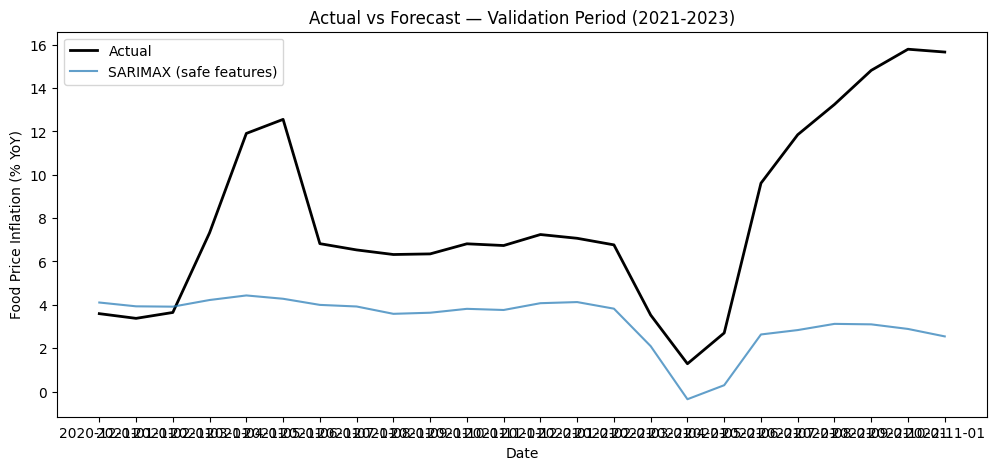

In [48]:
# forcasting visual(actual vs fitted/forcast plot)
plt.figure(figsize=(12,5))
plt.plot(val['year_month'], y_val, label='Actual', color='black', linewidth=2)
plt.plot(val['year_month'], val_forecast, label='SARIMAX (safe features)', alpha=0.7)
plt.legend()
plt.xlabel('Date')
plt.ylabel('Food Price Inflation (% YoY)')
plt.title('Actual vs Forecast — Validation Period (2021-2023)')
plt.savefig('../outputs/figures/sarimax_actual_vs_forecast.png', dpi=150, bbox_inches='tight')

      lb_stat  lb_pvalue
12  25.080078   0.014448


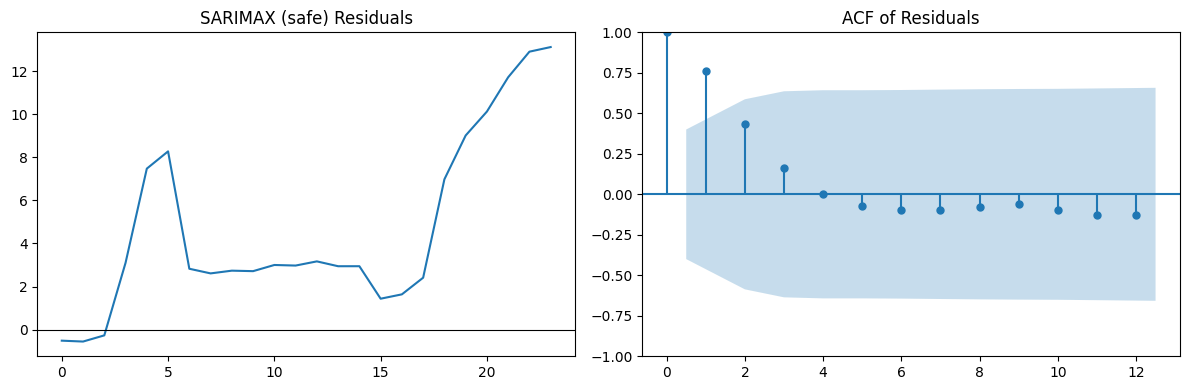

In [49]:
# residual diagnostics

residuals_safe = y_val.values - val_forecast.values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(residuals_safe)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('SARIMAX (safe) Residuals')
plot_acf(residuals_safe, ax=axes[1], lags=12)
axes[1].set_title('ACF of Residuals')
plt.tight_layout()
plt.savefig('../outputs/figures/sarimax_residuals_acf.png', dpi=150, bbox_inches='tight')
print(acorr_ljungbox(residuals_safe, lags=[12], return_df=True))


In [50]:
import os
print(os.listdir('../data/processed'))

['modelling_table_with_lags.csv', 'merge_diagnostics.csv', 'model_ready_data.csv', 'prediction_template_2024.csv', '.ipynb_checkpoints', 'merged_monthly_features.csv', 'data_dictionary.csv']


---
**➜ Next: `04_model_dnn.ipynb`** 